## Step 1: Introduction
This is my final evaluation notebook. I am comparing two models:
- Baseline model from `03_Modeling`
- Transfer Learning model from `04_TransferLearning` (MobileNetV2 fine-tuned)

In [22]:
import tensorflow as tf
from keras.utils import image_dataset_from_directory
from keras.applications.mobilenet_v2 import preprocess_input

In [23]:
# For dataset performance
AUTOTUNE = tf.data.AUTOTUNE

# --- Load Baseline CNN test dataset (one-hot labels) ---
baseline_test_ds = image_dataset_from_directory(
    "../data/split/test",
    image_size=(256, 256),
    batch_size=16,
    label_mode='categorical',  # One-hot labels here, because baseline trained with categorical_crossentropy
    shuffle=False
)
class_names = baseline_test_ds.class_names
baseline_test_ds = baseline_test_ds.prefetch(buffer_size=AUTOTUNE)


# --- Load Transfer Learning test dataset (integer labels) ---
AUTOTUNE = tf.data.AUTOTUNE

test_ds = image_dataset_from_directory(
    "../data/split/test",
    image_size=(224, 224),
    batch_size=16,
    label_mode='int',  # integer labels, same as training
    shuffle=False
)
class_names = test_ds.class_names
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 8339 files belonging to 39 classes.
Found 8339 files belonging to 39 classes.


In [24]:
# --- Load saved models ---
baseline_model = tf.keras.models.load_model("models/baseline_model.keras")
transfer_model = tf.keras.models.load_model("models/transfer_model.keras")

C:\Users\User\anaconda3\envs\strongenv\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\User\anaconda3\envs\strongenv\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 36 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
# --- Evaluate Baseline CNN model ---
print("Evaluating Baseline CNN Model:")
baseline_loss, baseline_acc = baseline_model.evaluate(baseline_test_ds, verbose=1)
print(f"Baseline CNN Model Accuracy: {baseline_acc:.4f}\n")

Evaluating Baseline CNN Model:
522/522 ━━━━━━━━━━━━━━━━━━━━ 71s 134ms/step - accuracy: 0.0527 - loss: 47.9673
Baseline CNN Model Accuracy: 0.0917



In [26]:
# --- Evaluate Transfer Learning model ---
print("Evaluating Transfer Learning Model:")
test_loss, test_accuracy = transfer_model.evaluate(test_ds, verbose=1)
print(f"Transfer Learning Model Accuracy: {test_accuracy:.4f}\n")

Evaluating Transfer Learning Model:
522/522 ━━━━━━━━━━━━━━━━━━━━ 148s 277ms/step - accuracy: 0.8648 - loss: 0.4086
Transfer Learning Model Accuracy: 0.8687



In [27]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
def get_labels_and_preds(model, dataset, is_sparse_labels=True):
    all_preds = []
    all_labels = []

    for images, labels in dataset:
        preds = model.predict(images)
        # For sparse labels: labels are integers, preds are probabilities
        if is_sparse_labels:
            pred_classes = np.argmax(preds, axis=1)
            all_preds.extend(pred_classes)
            all_labels.extend(labels.numpy())
        else:
            # For one-hot labels: labels are one-hot vectors
            pred_classes = np.argmax(preds, axis=1)
            true_classes = np.argmax(labels.numpy(), axis=1)
            all_preds.extend(pred_classes)
            all_labels.extend(true_classes)
    return np.array(all_labels), np.array(all_preds)

In [29]:
# Baseline model uses one-hot labels
baseline_true, baseline_pred = get_labels_and_preds(baseline_model, baseline_test_ds, is_sparse_labels=False)

# Transfer learning model uses sparse integer labels
transfer_true, transfer_pred = get_labels_and_preds(transfer_model, test_ds, is_sparse_labels=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [30]:
print("Baseline CNN Classification Report:\n")
print(classification_report(baseline_true, baseline_pred))

print("\nTransfer Learning Classification Report:\n")
print(classification_report(transfer_true, transfer_pred))

Baseline CNN Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        95
           1       0.00      0.00      0.00        94
           2       0.00      0.00      0.00        42
           3       0.00      0.00      0.00       247
           4       0.00      0.00      0.00       172
           5       0.00      0.00      0.00       226
           6       0.00      0.00      0.00       158
           7       0.00      0.00      0.00       129
           8       0.00      0.00      0.00        77
           9       0.00      0.00      0.00       179
          10       0.00      0.00      0.00       148
          11       0.00      0.00      0.00       175
          12       0.00      0.00      0.00       178
          13       0.00      0.00      0.00       208
          14       0.00      0.00      0.00       162
          15       0.00      0.00      0.00        64
          16       0.03      0.00      0.00 

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

Number of classes: 39


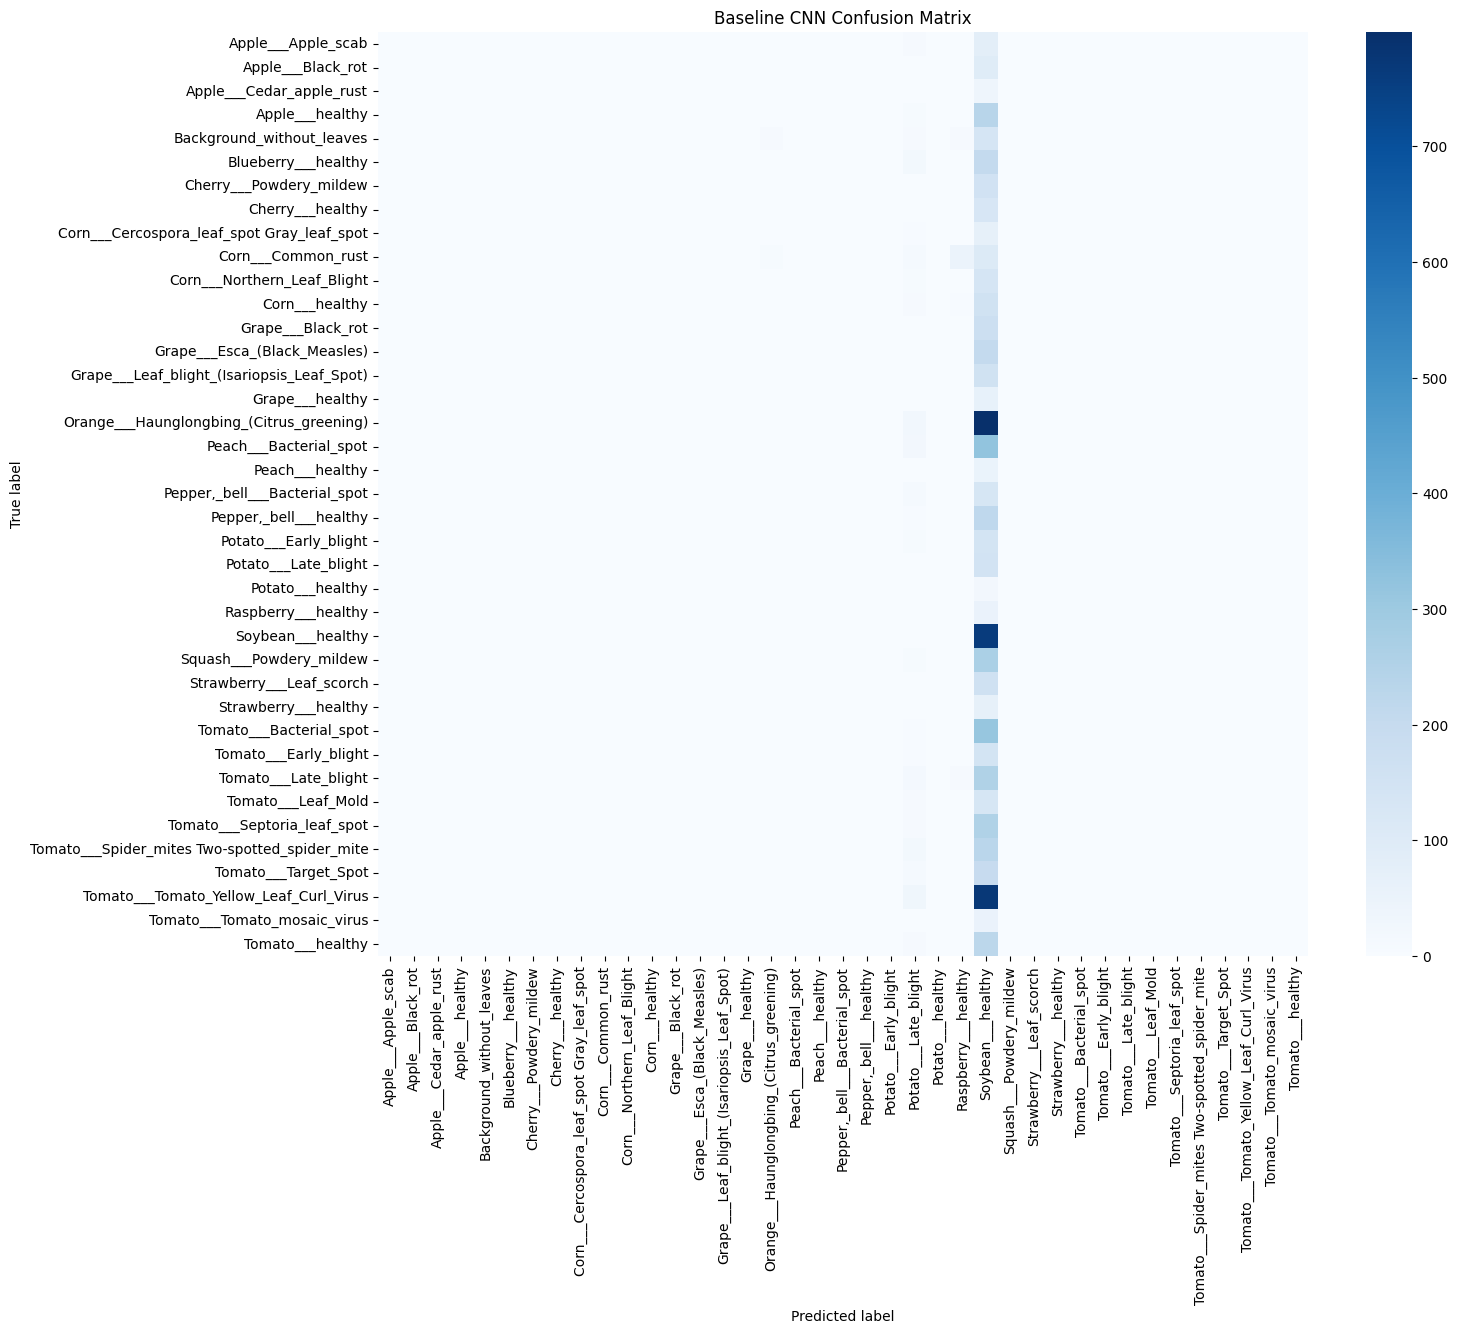

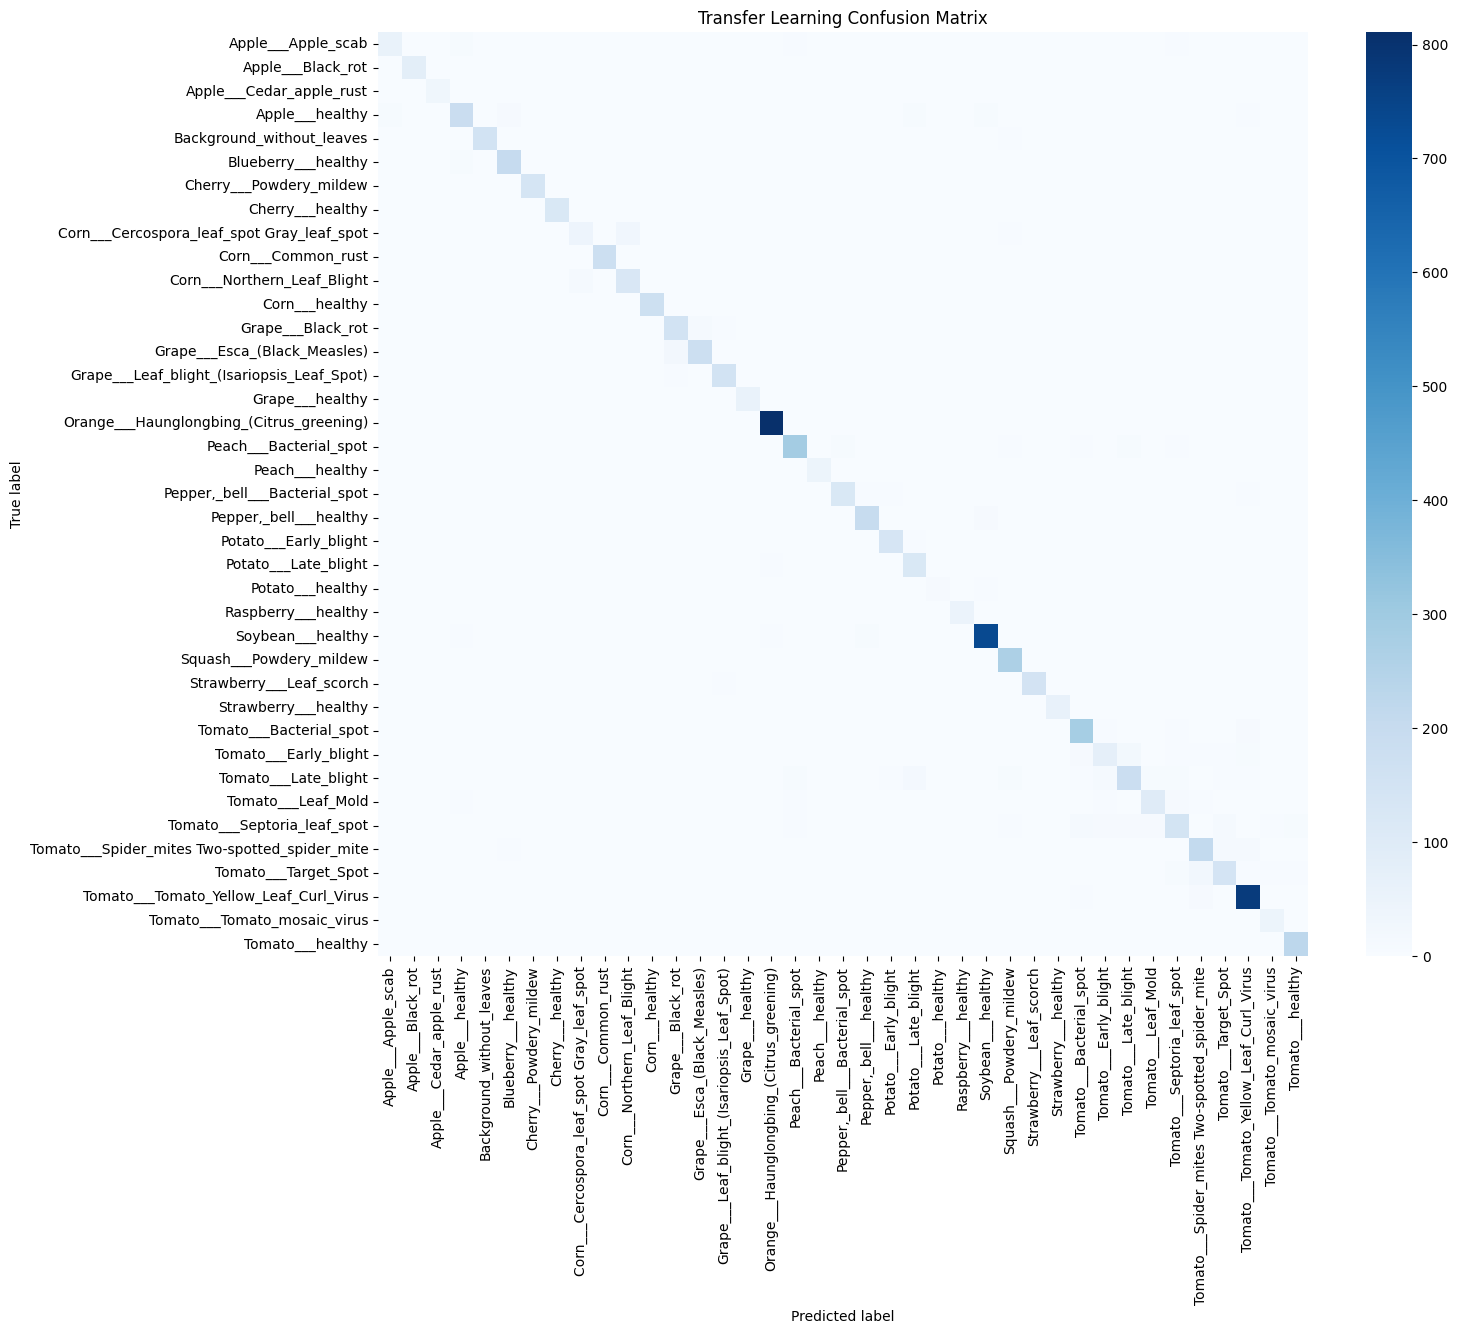

In [34]:
# Function to plot confusion matrix
def plot_conf_matrix(true_labels, pred_labels, class_names, title):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(15,12))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Use the class_names you got from dataset loading (make sure these match both datasets)
print(f"Number of classes: {len(class_names)}")

# Plot confusion matrices
plot_conf_matrix(baseline_true, baseline_pred, class_names, "Baseline CNN Confusion Matrix")
plot_conf_matrix(transfer_true, transfer_pred, class_names, "Transfer Learning Confusion Matrix")